### Purpose
Given a Pauli string $p$ what is the shortest path to get it to be "implementable" (defined as a Pauli String with a Pauli weight of 1 and the single qubit operation being Z)?
This is important to understand because solving this problem will create a subroutine for solving the shortest distance problem for a Pauli word $P = [p_{1}, p_{2}, ... p_{n}]$

To solve this first, we shall find the shortest path in a graph of Pauli strings from an arbitrary Pauli string to an implementable Pauli string. The total number of possible nodes is $4^{n + 1/2}$( the $1/2$ is to account for both positive and negative signs). Based on how, the paths form, an optimal or near optimal procedure can be made. 

In [86]:
import networkx as nx
import numpy as np 
import random as rnd

In [58]:
# class that implements tableau and necessary operations
# Reference -Improved Simulation of Stabilizer Circuits by Scott Aaronson & Daniel Gottesman
class Cirq_Tableau:
    
    def __init__(
        self,
        pauli_word: list[str] = None  
    ):
        if pauli_word is None or len(pauli_word) == 0:
            self._column_num = None
            self._row_num = None

            self._ss, self._xs, self._zs = None, None, None
        else:
            if "-" in pauli_word[0]:
                self._column_num = len(pauli_word[0][1:]) 
            else:
                self._column_num = len(pauli_word[0])
            self._row_num = len(pauli_word)

            self._ss = self.create_sign(pauli_word)
            self._xs, self._zs = self.create_tab(pauli_word)

    # setters & getters 
    @property
    def ss(self) -> np.ndarray:
        return self._ss

    @ss.setter 
    def ss(self, new_ss: np.ndarray):
        self._ss = new_ss
        
    @property
    def xs(self) -> np.ndarray:
        return self._xs

    @xs.setter 
    def xs(self, new_xs: np.ndarray):
        self._xs = new_xs
        
    @property
    def zs(self) -> np.ndarray:
        return self._zs

    @zs.setter 
    def zs(self, new_zs: np.ndarray):
        self._zs = new_zs
        
    @property
    def column_num(self) -> int:
        return self._column_num

    @column_num.setter 
    def column_num(self, new_num: int):
        self._column_num = new_num
    
    @property
    def row_num(self) -> int:
        return self._row_num

    @row_num.setter 
    def row_num(self, new_num: int):
        self._row_num = new_num

    # functions that create parts of tableau
    def create_sign(self, pauli_word: list[str]):
        temp_ss = np.zeros((self.row_num), dtype=int)
        for pauli_string in pauli_word:
            if "-" in pauli_string:
                index = pauli_word.index(pauli_string)
                pauli_word[index] = pauli_string.replace("-", "")
                #print(pauli_word)
                temp_ss[index] = 1
        return temp_ss
        
    def create_tab(self, pauli_word: list[str]):
        temp_x = np.zeros((self.row_num, self.column_num), dtype=int)
        temp_z = np.zeros((self.row_num, self.column_num), dtype=int)
        for i, pauli_string in enumerate(pauli_word):
            for j, pauli in enumerate(pauli_string):
                if pauli == "X" or pauli == "Y":
                    temp_x[i][j] = 1
                if pauli == "Z" or pauli == "Y":
                    temp_z[i][j] = 1
        return temp_x, temp_z

    # Clifford operations on tableau. 
    def apply_H(self,column: int):
        self.ss ^= self.xs[:, column] & self.zs[:, column]
        self.xs[:, column], self.zs[:, column] = self.zs[:, column].copy(), self.xs[:, column].copy()

    def apply_S(self, column: int):
        self.ss ^= self.xs[:, column] & self.zs[:, column]
        self.zs[:, column] = self.xs[:, column] ^ self.zs[:, column]

    def apply_CX(self, control: int, target: int):
        self.ss ^= (
            (self.xs[:, control] & self.zs[:, target])
            &(~(self.xs[:, target] ^ self.zs[:, control]))
        )
        self.xs[:, target] ^= self.xs[:, control]
        self.zs[:, control] ^= self.zs[:, target]

    # class operations necessary for comparisons and equating
    def copy(self):
        new_tab = Cirq_Tableau()
        new_tab.column_num = self.column_num
        new_tab.row_num = self.row_num
        new_tab.ss = self.ss.copy()
        new_tab.zs = self.zs.copy()
        new_tab.xs = self.xs.copy()
        return new_tab
    
    def __eq__(self, other):
        if not isinstance(other, type(self)):
            return NotImplemented  
        return (
            self.column_num == other.column_num
            and self.row_num == other.row_num
            and np.array_equal(self.ss, other.ss)
            and np.array_equal(self.xs, other.xs)
            and np.array_equal(self.zs, other.zs)
        )
    
    def return_string(self):
        string = ''
        for i in range(self.row_num):
            if self.ss[i]:
                string += "-"  

            for j in range(self.column_num):
                if self.xs[i][j] and not self.zs[i][j]:
                    string += "X"
                elif not self.xs[i][j] and self.zs[i][j]:
                    string += "Z"
                elif self.xs[i][j] and self.zs[i][j]:
                    string += "Y"
                else:
                    string += "I"
            if i < self.row_num - 1:
                string += "\n" 

        return string
    
    def __copy__(self):
        return self.copy()
        

    def __str__(self) -> str:
        ss = np.expand_dims(self.ss, axis = 1)
        xz = np.concatenate((self.xs, self.zs, ss), axis=1)
        return str(xz)

    def __hash__(self) -> int:
        return hash(self.zs.tobytes() + self.xs.tobytes() + self.ss.tobytes())

    def __lt__(self, other):
        return self.row_num < other.row_num

In [59]:
tab = Cirq_Tableau(["-XYZ"])
print(tab)
tab.return_string()

[[1 1 0 0 1 1 1]]


'-XYZ'

In [179]:
def graph_creator(init: str, digraph):
    open_list = [init]
    closed_list = []

    while open_list:
        node = open_list[0]
        tableau = Cirq_Tableau([node])
        closed_list.append(node)
        del open_list[0]
        num_qubits = tableau.column_num
        for i in range(num_qubits):
            if i != (num_qubits - 1):
                for j in range((i+1), num_qubits):
                    tab1, tab2 = tableau.copy(), tableau.copy()
                    tab1.apply_CX(i, j)
                    tab2.apply_CX(j, i)
                    next_node1, next_node2 = tab1.return_string(), tab2.return_string()
                    digraph.add_edge(node, next_node1, weight =1, label=("CX", i, j))
                    digraph.add_edge(node, next_node2, weight =1, label=("CX", j, i))
                    if next_node1 not in closed_list:
                        open_list.append(next_node1)
                    if next_node2 not in closed_list:
                        open_list.append(next_node2)
                    
            tab3, tab4 = tableau.copy(), tableau.copy()
            tab3.apply_S(i)
            tab4.apply_H(i)
            next_node3, next_node4 = tab3.return_string(), tab4.return_string()
            digraph.add_edge(node, next_node3, weight =0, label=("S", i))
            digraph.add_edge(node, next_node4, weight =0, label=("H", i))
            if next_node3 not in closed_list:
                open_list.append(next_node3)
            if next_node4 not in closed_list:
                open_list.append(next_node4)

In [180]:
G = nx.DiGraph()
graph_creator("XX", G)

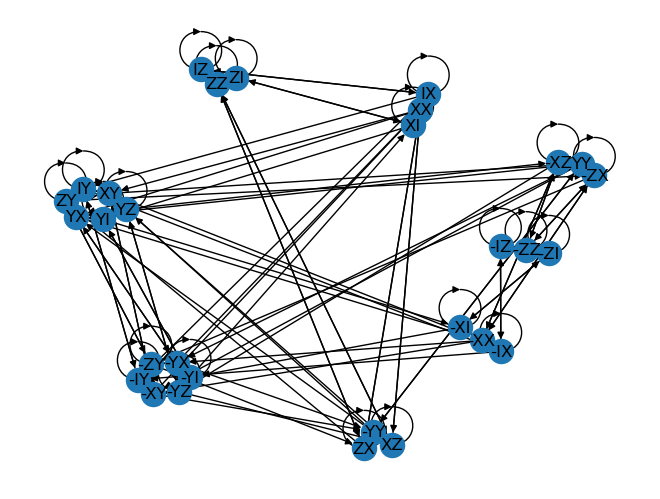

In [181]:
pos = layout=nx.spring_layout(DG, scale=10)
nx.draw(G, with_labels=True)

In [182]:
len(G.nodes())

30

In [183]:
DG = nx.DiGraph()
graph_creator("XXXX", DG)

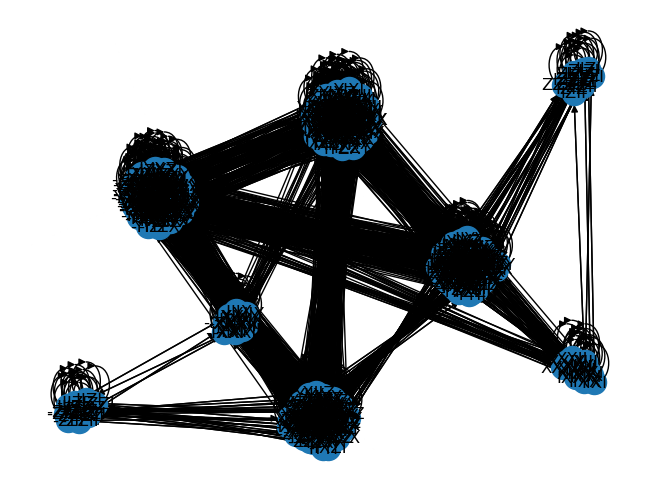

In [184]:
pos = layout=nx.spring_layout(DG, scale=10)
nx.draw(DG, pos, with_labels=True)

In [185]:
len(DG.nodes())

510

In [186]:
random_pauli = rnd.sample(list(DG.nodes()), 20)
random_pauli

['-XIZZ',
 '-XZXI',
 'ZZYY',
 'ZXIZ',
 'YIIX',
 'IIXZ',
 'YIII',
 'YIIY',
 '-ZXYZ',
 'ZYYY',
 'YIZY',
 '-XYZI',
 'YXXZ',
 'ZXXY',
 '-ZXXX',
 '-YXYX',
 '-ZYXY',
 '-ZYIX',
 'ZYXZ',
 '-IXIX']

In [187]:
targets = [
    "IIIZ",
    "IIZI",
    "IZII",
    "ZIII",
    "-IIIZ",
    "-IIZI",
    "-IZII",
    "-ZIII",
]

In [191]:
for pauli in random_pauli:
    print(f"paths from {pauli}")
    for end in targets:
        operations = []
        path = nx.shortest_path(DG, source=pauli, target=end, weight='weight')
        print(path)
        for i in range(len(path)-1):
            operations.append(DG[path[i]][path[i+1]]['label'])
        print(operations)
        print(f"Number of CNOTs {nx.path_weight(DG, path, 'weight')}")
        print()
    print()    

paths from -XIZZ
['-XIZZ', '-ZIZZ', '-ZIIZ', '-IIIZ', '-IIIX', '-IIIY', 'IIIX', 'IIIZ']
[('H', 0), ('CX', 2, 3), ('CX', 0, 3), ('H', 3), ('S', 3), ('S', 3), ('H', 3)]
Number of CNOTs 2

['-XIZZ', '-ZIZZ', '-IIZZ', '-IIZI', '-IIXI', '-IIYI', 'IIXI', 'IIZI']
[('H', 0), ('CX', 0, 3), ('CX', 3, 2), ('H', 2), ('S', 2), ('S', 2), ('H', 2)]
Number of CNOTs 2

['-XIZZ', '-XXZZ', '-IXZZ', '-IXIZ', '-IYIZ', '-IYII', 'IXII', 'IZII']
[('CX', 0, 1), ('CX', 1, 0), ('CX', 2, 3), ('S', 1), ('CX', 3, 1), ('S', 1), ('H', 1)]
Number of CNOTs 4

['-XIZZ', '-YIZZ', '-YIIZ', '-YIII', 'XIII', 'ZIII']
[('S', 0), ('CX', 2, 3), ('CX', 3, 0), ('S', 0), ('H', 0)]
Number of CNOTs 2

['-XIZZ', '-ZIZZ', '-IIZZ', '-IIIZ']
[('H', 0), ('CX', 0, 3), ('CX', 2, 3)]
Number of CNOTs 2

['-XIZZ', '-ZIZZ', '-IIZZ', '-IIZI']
[('H', 0), ('CX', 0, 3), ('CX', 3, 2)]
Number of CNOTs 2

['-XIZZ', '-XXZZ', '-IXZZ', '-IXIZ', '-IZIZ', '-IZII']
[('CX', 0, 1), ('CX', 1, 0), ('CX', 2, 3), ('H', 1), ('CX', 3, 1)]
Number of CNOTs 4

['-XIZ